##Importing libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

##Loading Dataset

In [ ]:
df = pd.read_csv('/content/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


##Basic Data Exploration

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


##Data Cleaning

In [4]:
df.dropna(inplace=True)

# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Display cleaned info and check for nulls
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [5]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

df.info()

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


##Exploratory Data Analysis (EDA)

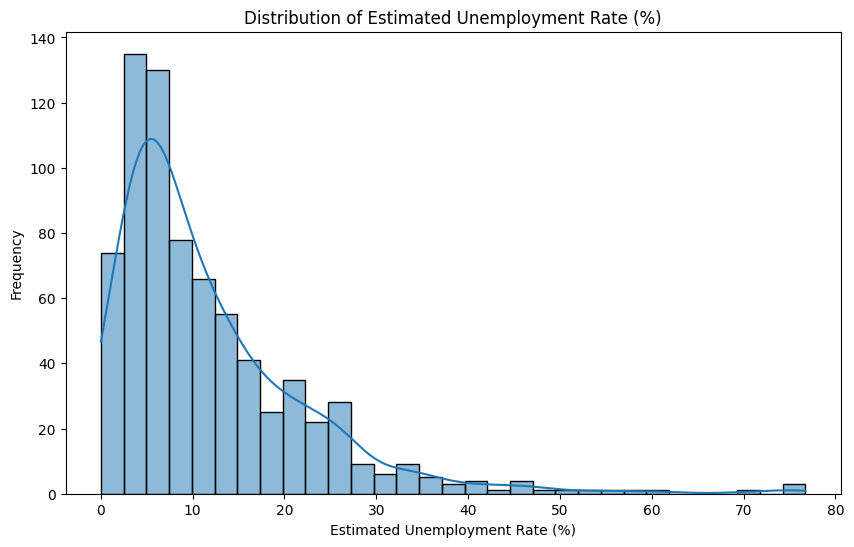

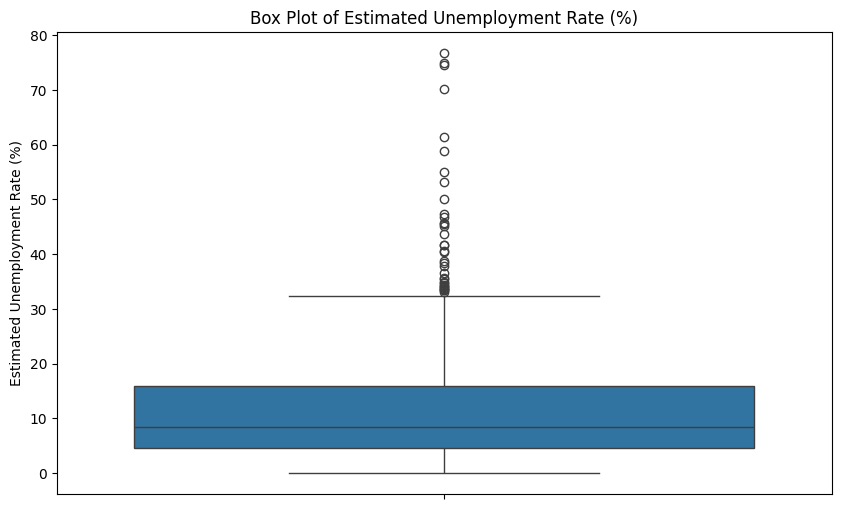

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True)
plt.title('Distribution of Estimated Unemployment Rate (%)')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Estimated Unemployment Rate (%)'])
plt.title('Box Plot of Estimated Unemployment Rate (%)')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.show()

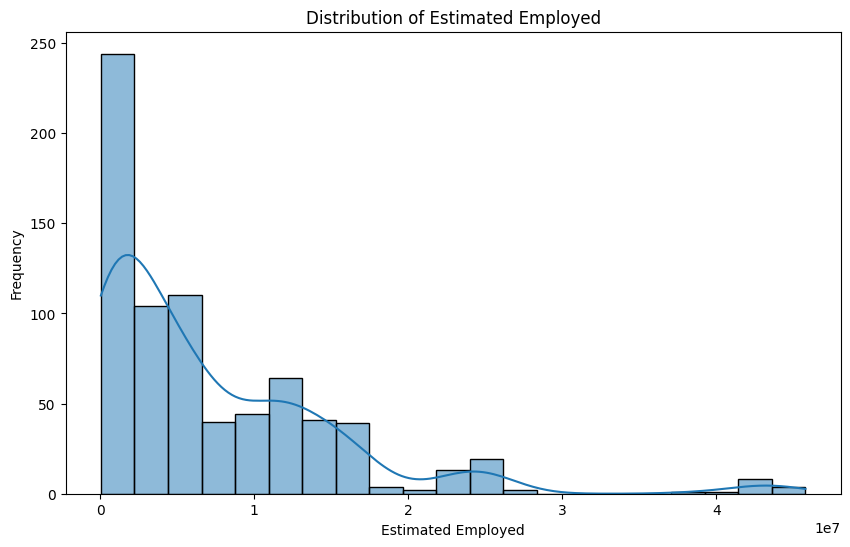

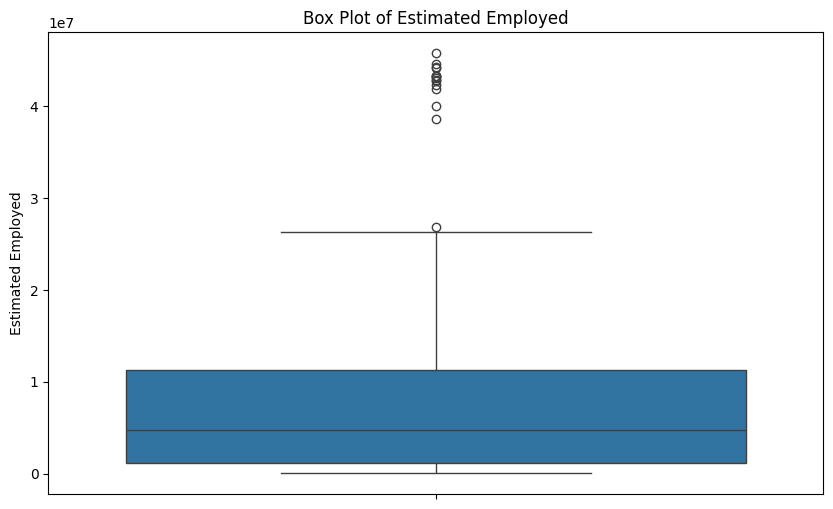

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated Employed'], kde=True)
plt.title('Distribution of Estimated Employed')
plt.xlabel('Estimated Employed')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Estimated Employed'])
plt.title('Box Plot of Estimated Employed')
plt.ylabel('Estimated Employed')
plt.show()

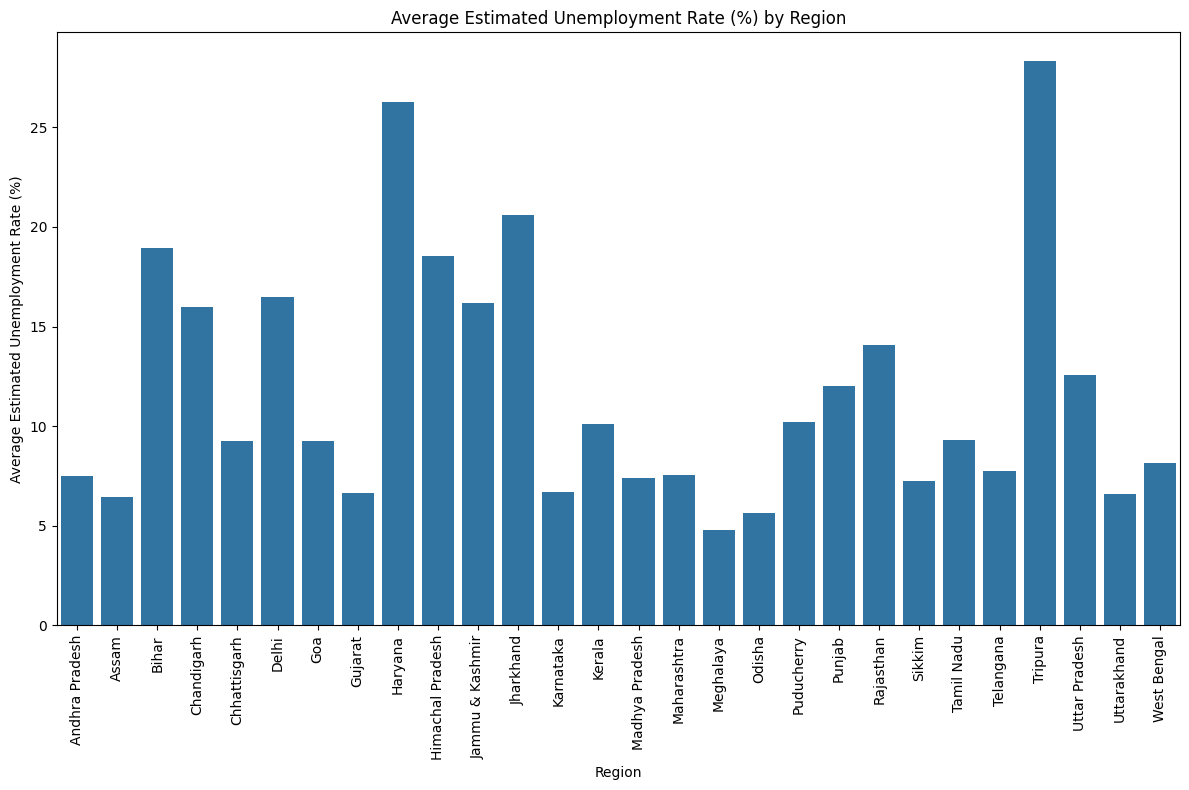

In [9]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index())
plt.xticks(rotation=90)
plt.title('Average Estimated Unemployment Rate (%) by Region')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.tight_layout()
plt.show()

##Visualize Unemployment Trends

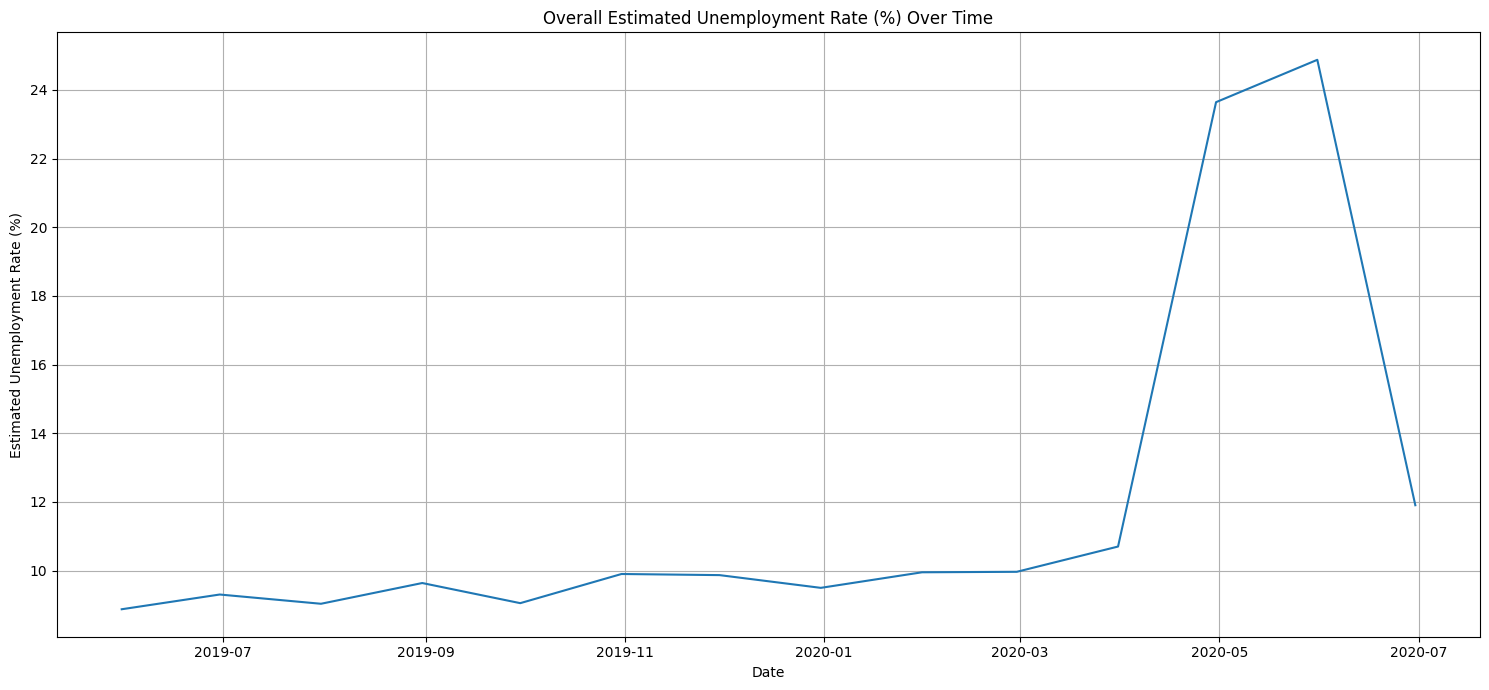

In [10]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index())
plt.title('Overall Estimated Unemployment Rate (%) Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

##Covid-19 Impact Analysis

Average Unemployment Rate (Pre-COVID): 9.51%
Average Unemployment Rate (During COVID): 17.77%


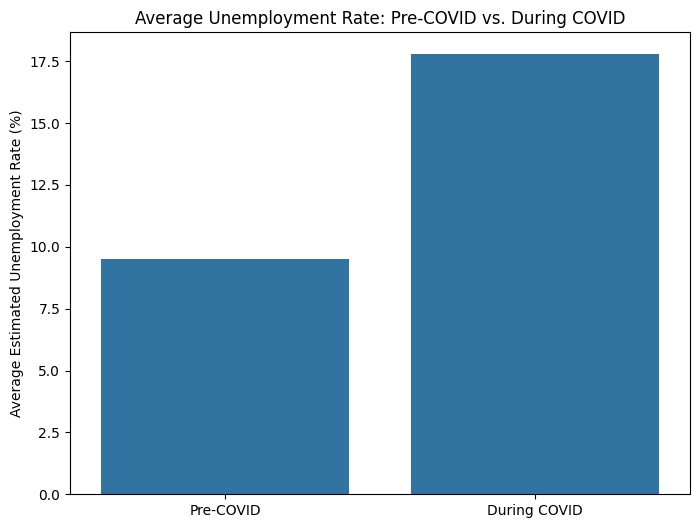

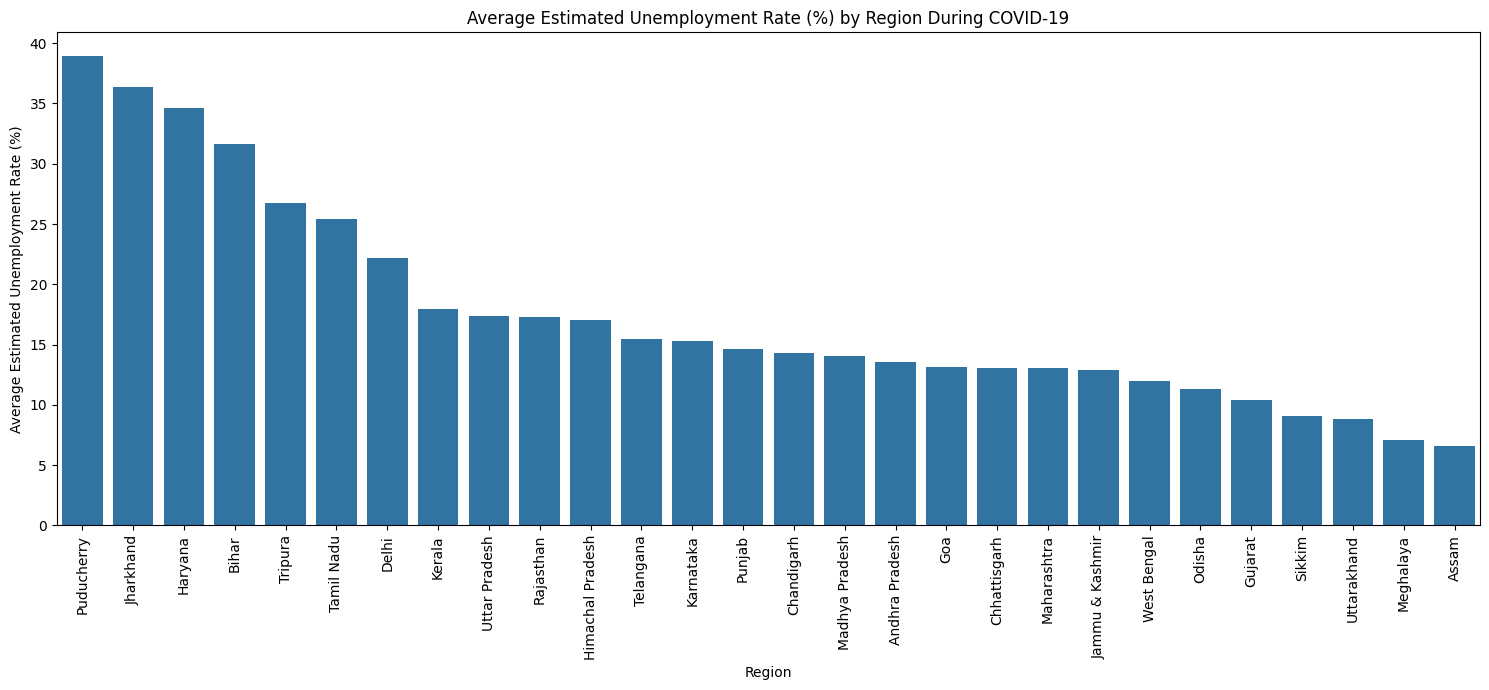

In [11]:
df_copy = df.copy()

# Define the pre-COVID and during-COVID periods (assuming COVID impact from March 2020)
pre_covid_df = df_copy[df_copy['Date'] < '2020-03-01']
covid_df = df_copy[df_copy['Date'] >= '2020-03-01']

# Calculate average unemployment rate for both periods
pre_covid_unemployment = pre_covid_df['Estimated Unemployment Rate (%)'].mean()
covid_unemployment = covid_df['Estimated Unemployment Rate (%)'].mean()

print(f"Average Unemployment Rate (Pre-COVID): {pre_covid_unemployment:.2f}%")
print(f"Average Unemployment Rate (During COVID): {covid_unemployment:.2f}%")

# Visualize the comparison
plt.figure(figsize=(8, 6))
sns.barplot(x=['Pre-COVID', 'During COVID'], y=[pre_covid_unemployment, covid_unemployment])
plt.title('Average Unemployment Rate: Pre-COVID vs. During COVID')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.show()

# Further analysis: Regional impact during COVID
plt.figure(figsize=(15, 7))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=covid_df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().sort_values(by='Estimated Unemployment Rate (%)', ascending=False))
plt.xticks(rotation=90)
plt.title('Average Estimated Unemployment Rate (%) by Region During COVID-19')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.tight_layout()
plt.show()

##Regional Analysis

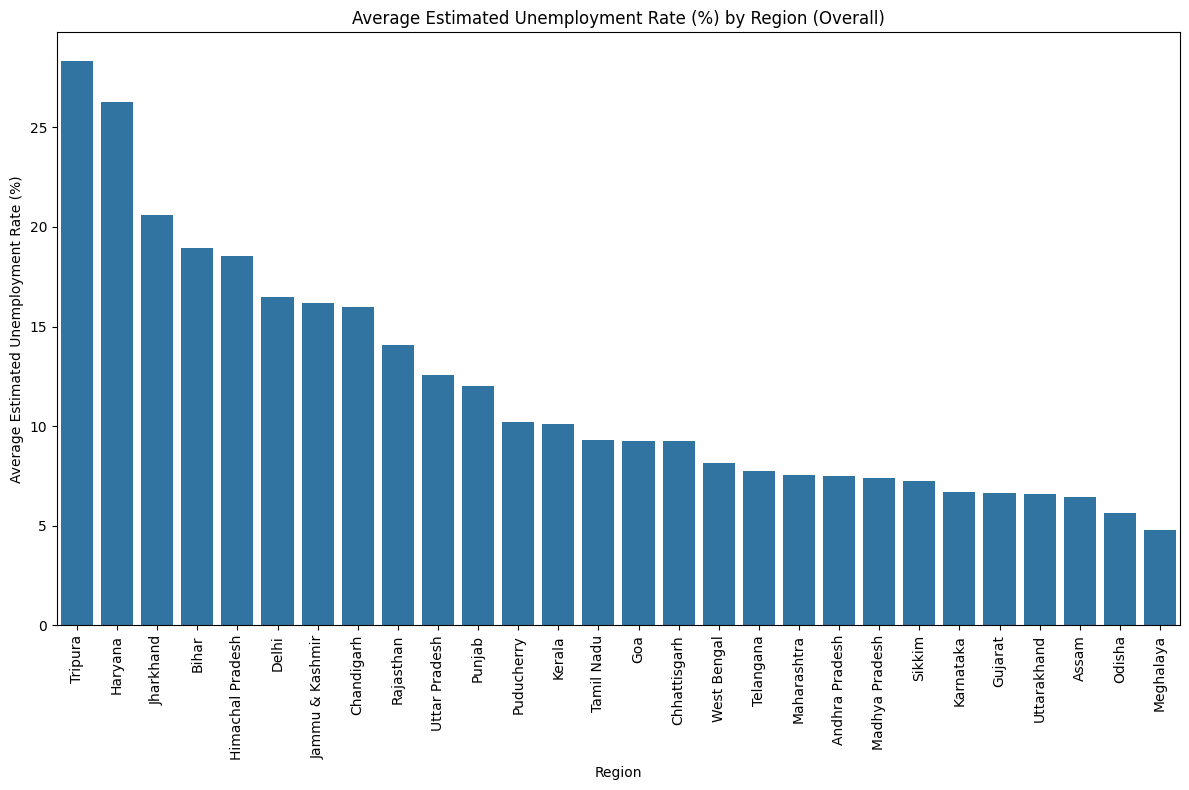

In [14]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().sort_values(by='Estimated Unemployment Rate (%)', ascending=False))
plt.xticks(rotation=90)
plt.title('Average Estimated Unemployment Rate (%) by Region (Overall)')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.tight_layout()
plt.show()

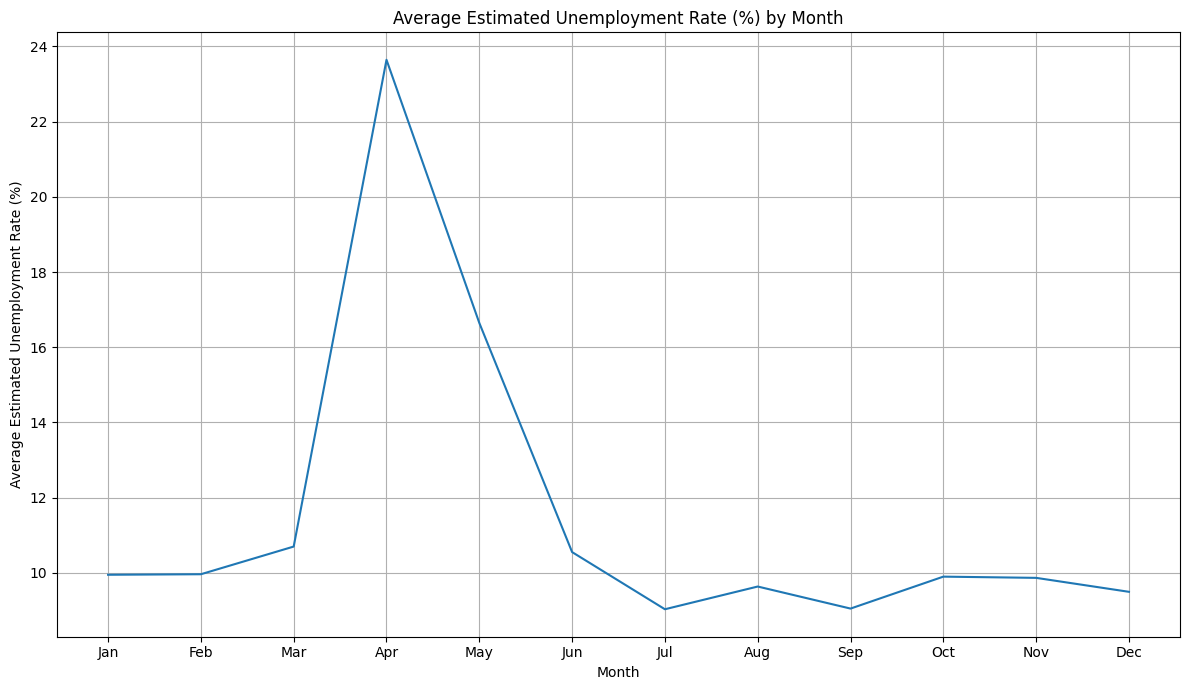

In [15]:
df['Month'] = df['Date'].dt.month
monthly_avg_unemployment = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', data=monthly_avg_unemployment)
plt.title('Average Estimated Unemployment Rate (%) by Month')
plt.xlabel('Month')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

##Seasonal Trend Analysis

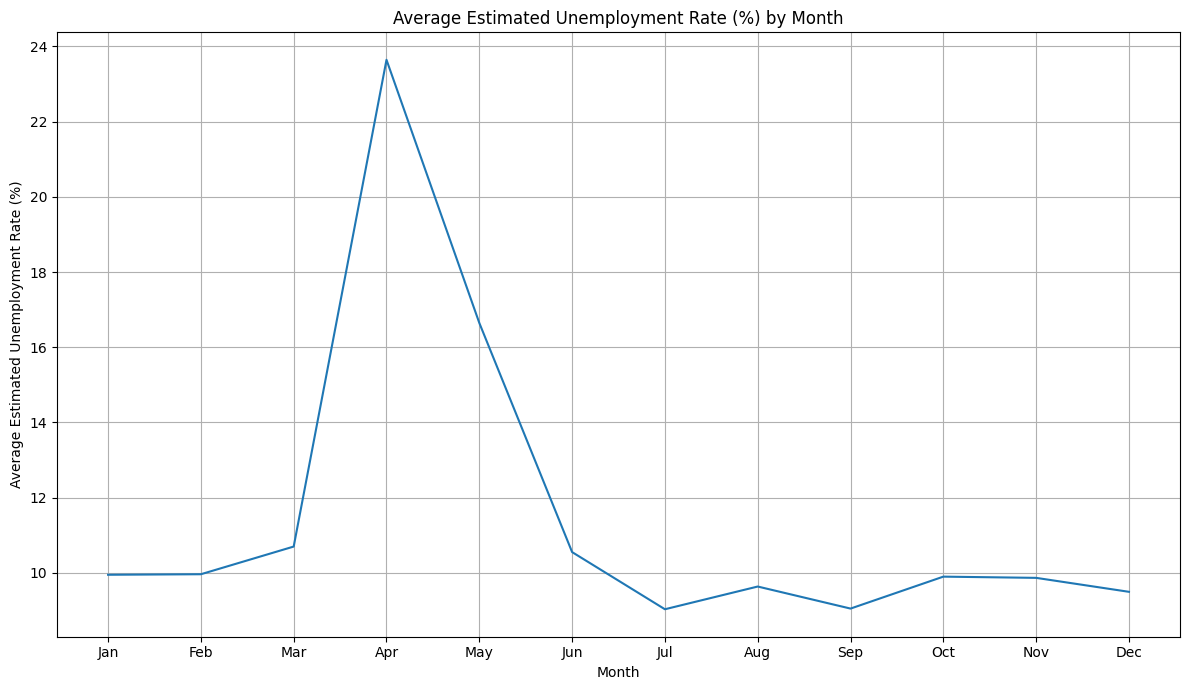

In [16]:
df['Month'] = df['Date'].dt.month
monthly_avg_unemployment = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', data=monthly_avg_unemployment)
plt.title('Average Estimated Unemployment Rate (%) by Month')
plt.xlabel('Month')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

##Heatmap Visualization

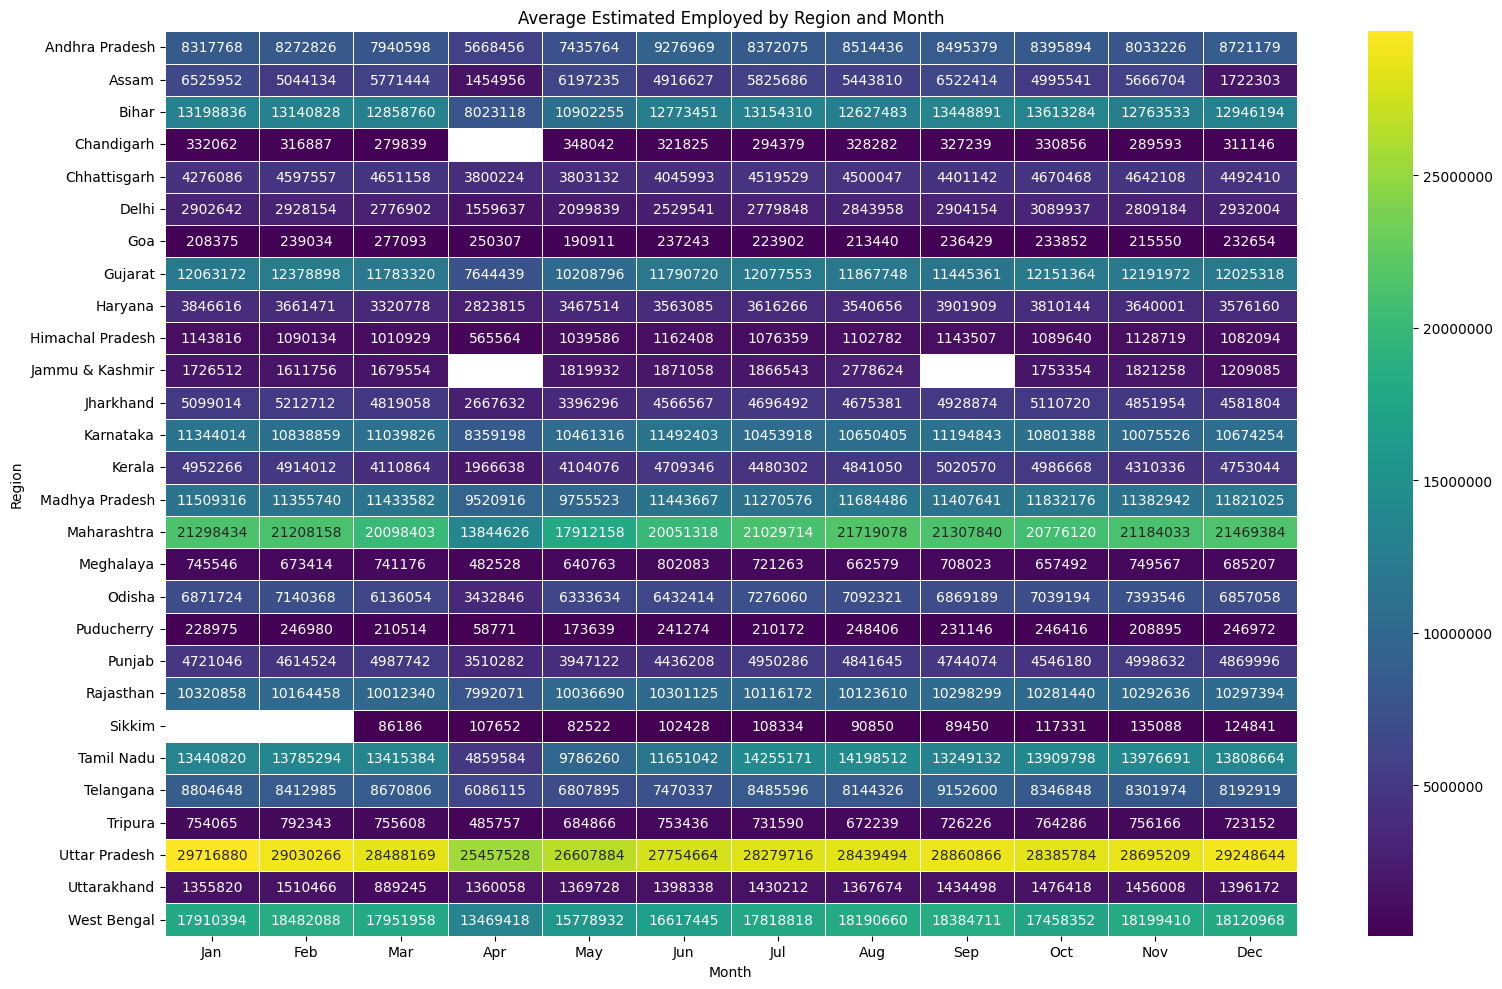

In [18]:
employed_pivot = df.pivot_table(index='Region', columns='Month', values='Estimated Employed', aggfunc='mean')

plt.figure(figsize=(16, 10))
sns.heatmap(employed_pivot, annot=True, cmap='viridis', fmt='.0f', linewidths=.5, cbar_kws={'format': '%.0f'})
plt.title('Average Estimated Employed by Region and Month')
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(ticks=np.arange(12) + 0.5, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

## Policy Suggestions

Based on the data analysis, here are some policy suggestions to address unemployment in India:

*   **Targeted Interventions for COVID-19 Impact:** The significant surge in unemployment during the COVID-19 period (from ~9.5% to ~17.8%) highlights the need for robust economic support and job protection schemes during health crises. Policies could include: wage subsidies, temporary unemployment benefits, and support for businesses to retain employees or facilitate remote work.
*   **Regional Development Programs:** The heatmap visualizations showed varying employment and unemployment rates across regions and months. This indicates that one-size-fits-all policies might not be effective. Developing region-specific employment generation programs, focusing on industries prevalent in those regions, could be beneficial.
*   **Seasonal Employment Support:** The seasonal trend analysis showed fluctuations in unemployment rates throughout the year. Policies could aim to create more stable employment opportunities in sectors that are traditionally seasonal or provide training programs that allow workers to transition between sectors during off-peak seasons.
*   **Skill Development and Retraining:** To adapt to economic shifts and unforeseen events (like the pandemic), continuous skill development and retraining programs are crucial to ensure the workforce remains adaptable and employable.

##Forecasting

/tmp/ipykernel_4940/1016751459.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_series_data = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().resample('M').mean().ffill()
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


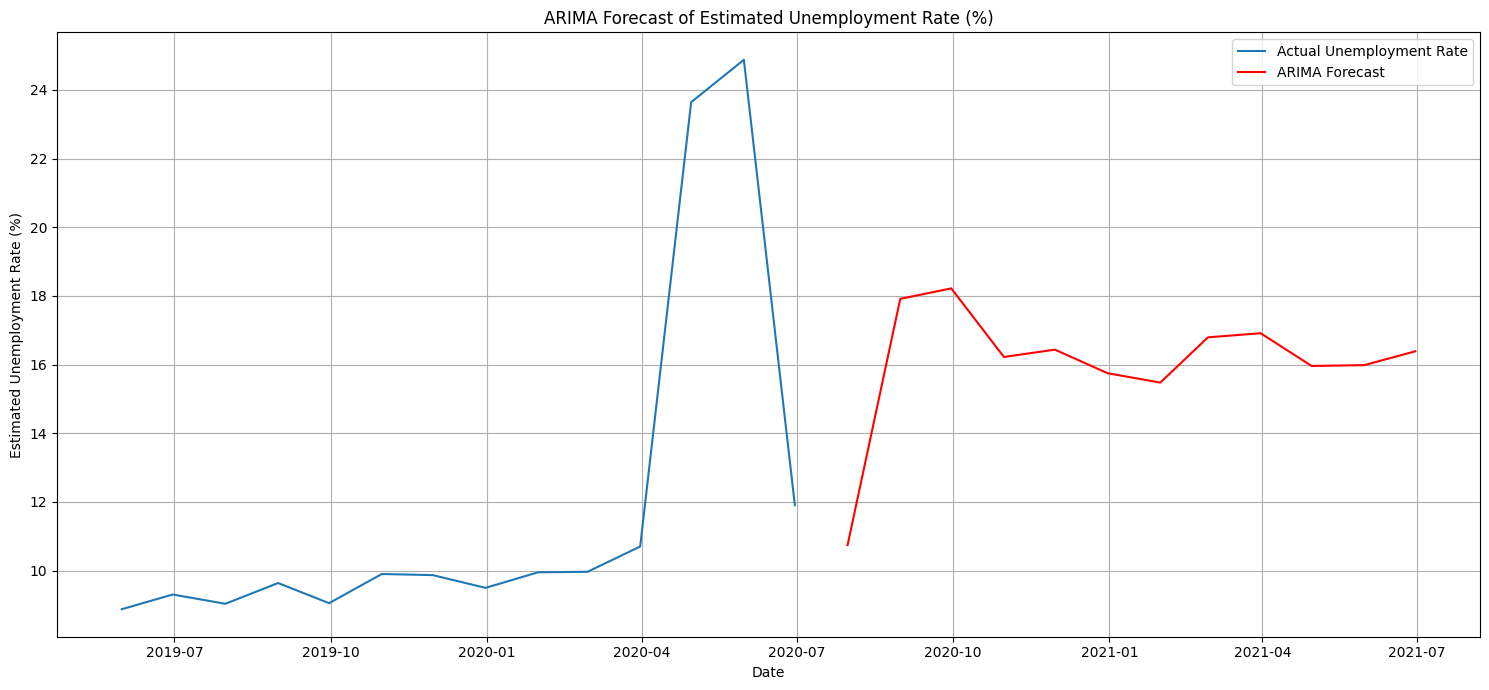

ARIMA Model Summary:
                                      SARIMAX Results                                      
Dep. Variable:     Estimated Unemployment Rate (%)   No. Observations:                   14
Model:                              ARIMA(5, 1, 0)   Log Likelihood                 -35.947
Date:                             Wed, 27 May 2026   AIC                             83.895
Time:                                     05:35:43   BIC                             87.284
Sample:                                 05-31-2019   HQIC                            83.198
                                      - 06-30-2020                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2126      1.755      0.121      0.904      -3.227       3.652
ar.L2 

In [20]:
# Prepare data for forecasting
time_series_data = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().resample('M').mean().ffill()

# Fit ARIMA model (e.g., order (5,1,0))
# The order (p,d,q) represents (AR order, differencing order, MA order)
# Here, d=1 for first-order differencing to make the series stationary
model = ARIMA(time_series_data, order=(5,1,0))
model_fit = model.fit()

# Make predictions
forecast_steps = 12 # Forecast for the next 12 months
forecast = model_fit.forecast(steps=forecast_steps)

# Visualize the forecast
plt.figure(figsize=(15, 7))
plt.plot(time_series_data.index, time_series_data, label='Actual Unemployment Rate')
plt.plot(forecast.index, forecast, color='red', label='ARIMA Forecast')
plt.title('ARIMA Forecast of Estimated Unemployment Rate (%)')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ARIMA Model Summary:")
print(model_fit.summary())